Step 1 — Data Ingestion & Cleaning

Download both datasets (you'll need to share them as uploaded files)
Parse dates, handle nulls, normalize column names
Merge trader data with fear/greed index on date

Step 2 — Exploratory Data Analysis (EDA)

Distribution of trades across Fear vs Greed days
PnL statistics by sentiment classification
Most traded symbols, leverage patterns, trade sizes
Win rate and avg PnL per trader segmented by sentiment

Step 3 — Sentiment × Performance Analysis

Do traders profit more on Fear days or Greed days?
Long vs Short bias during different sentiment regimes
Does high leverage correlate with sentiment extremes?
Best/worst performing traders — are they sentiment-aware?

Step 4 — Pattern Discovery

Identify "smart money" traders who consistently beat the market
Detect contrarian vs momentum trading behavior
Look for sentiment-driven entry/exit timing patterns
Rolling PnL trends aligned with sentiment shifts

Step 5 — Visualization & Insights Dashboard

Interactive charts: PnL by sentiment, trade volume over time, win rates
Heatmaps of performance across sentiment buckets
Trader leaderboard with sentiment alignment score

Step 6 — Deliverable

A clean report/notebook summarizing findings with actionable strategy recommendations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Load Data

In [4]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print(trades.shape, fg.shape)
trades.head(3)

(211224, 16) (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


# Parse Dates & Merge

In [6]:
# Parse trade date
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

# Merge sentiment onto every trade
trades = trades.merge(fg[['date','value','classification']], on='date', how='left')

print("Merge done. Nulls in classification:", trades['classification'].isna().sum())
trades[['date','Side','Closed PnL','classification','value']].head(5)

Merge done. Nulls in classification: 6


,date,Side,Closed PnL,classification,value
0,2024-12-02,BUY,0.0,Extreme Greed,80.0
1,2024-12-02,BUY,0.0,Extreme Greed,80.0
2,2024-12-02,BUY,0.0,Extreme Greed,80.0
3,2024-12-02,BUY,0.0,Extreme Greed,80.0
4,2024-12-02,BUY,0.0,Extreme Greed,80.0


In [7]:
print(trades.dtypes)
print("\nSentiment breakdown:\n", trades['classification'].value_counts())
print("\nDate range:", trades['date'].min(), "→", trades['date'].max())

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
date                 object
value               float64
classification       object
dtype: object

Sentiment breakdown:
 classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Date range: 2023-05-01 → 2025-05-01


# PnL Basics

In [8]:
print(trades['Closed PnL'].describe())
print("\nTotal PnL: $", round(trades['Closed PnL'].sum(), 2))
print("Profitable trades:", (trades['Closed PnL'] > 0).sum())
print("Losing trades:", (trades['Closed PnL'] < 0).sum())

count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64

Total PnL: $ 10296958.94
Profitable trades: 86869
Losing trades: 17539


# Trade Volume by Sentiment

In [9]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

vol = trades.groupby('classification').agg(
    trade_count=('Closed PnL', 'count'),
    total_usd=('Size USD', 'sum'),
    avg_pnl=('Closed PnL', 'mean')
).reindex(sentiment_order)

print(vol)

                trade_count     total_usd    avg_pnl
classification                                      
Extreme Fear          21400  1.144843e+08  34.537862
Fear                  61837  4.833248e+08  54.290400
Neutral               37686  1.802421e+08  34.307718
Greed                 50303  2.885825e+08  42.743559
Extreme Greed         39992  1.244652e+08  67.892861


# Win Rate by Sentiment

In [10]:
trades['is_win'] = trades['Closed PnL'] > 0

winrate = trades.groupby('classification')['is_win'].mean().reindex(sentiment_order) * 100
print(winrate.round(2))

classification
Extreme Fear     37.06
Fear             42.08
Neutral          39.70
Greed            38.48
Extreme Greed    46.49
Name: is_win, dtype: float64


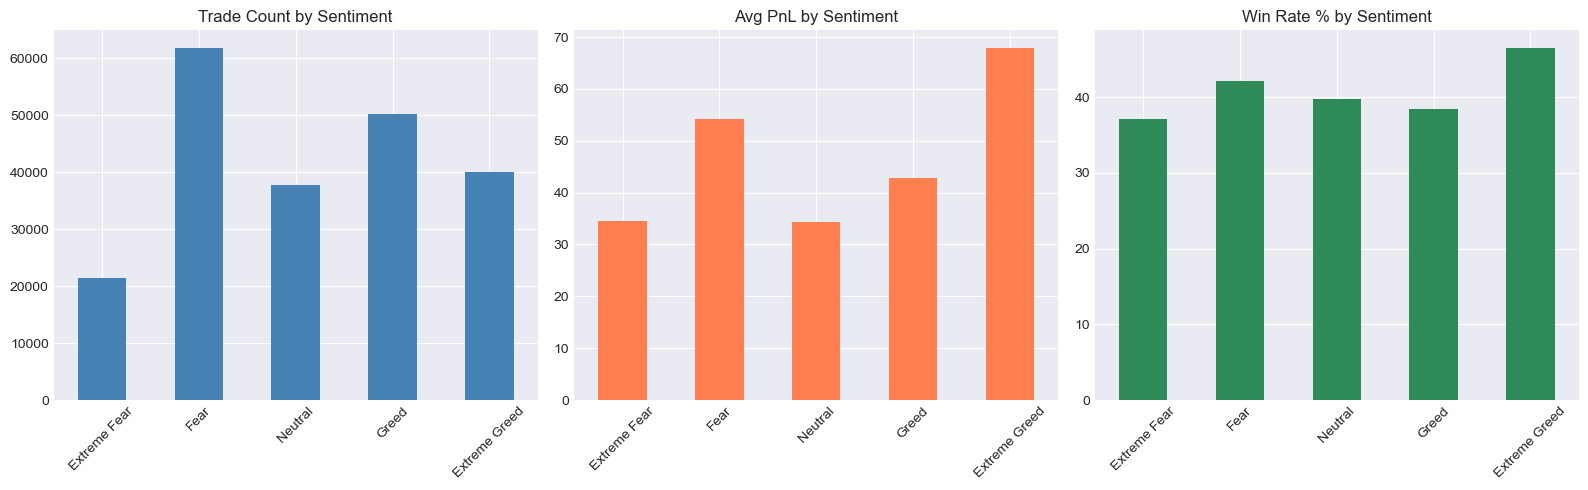

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vol['trade_count'].plot(kind='bar', ax=axes[0], color='steelblue', title='Trade Count by Sentiment')
vol['avg_pnl'].plot(kind='bar', ax=axes[1], color='coral', title='Avg PnL by Sentiment')
winrate.plot(kind='bar', ax=axes[2], color='seagreen', title='Win Rate % by Sentiment')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Phase 3 — Sentiment × Direction Analysis

## Long vs Short by Sentiment

In [12]:
direction = trades.groupby(['classification', 'Side'])['Closed PnL'].count().unstack()
direction = direction.reindex(sentiment_order)
print(direction)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Fear            30270  31567
Neutral         18969  18717
Greed           24576  25727
Extreme Greed   17940  22052


## Avg PnL by Sentiment + Side

In [15]:
pnl_side = trades.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack()
pnl_side = pnl_side.reindex(sentiment_order)
print(pnl_side)

Side                  BUY        SELL
classification                       
Extreme Fear    34.114627   34.980106
Fear            63.927104   45.049641
Neutral         29.227429   39.456408
Greed           25.002302   59.691091
Extreme Greed   10.498927  114.584643


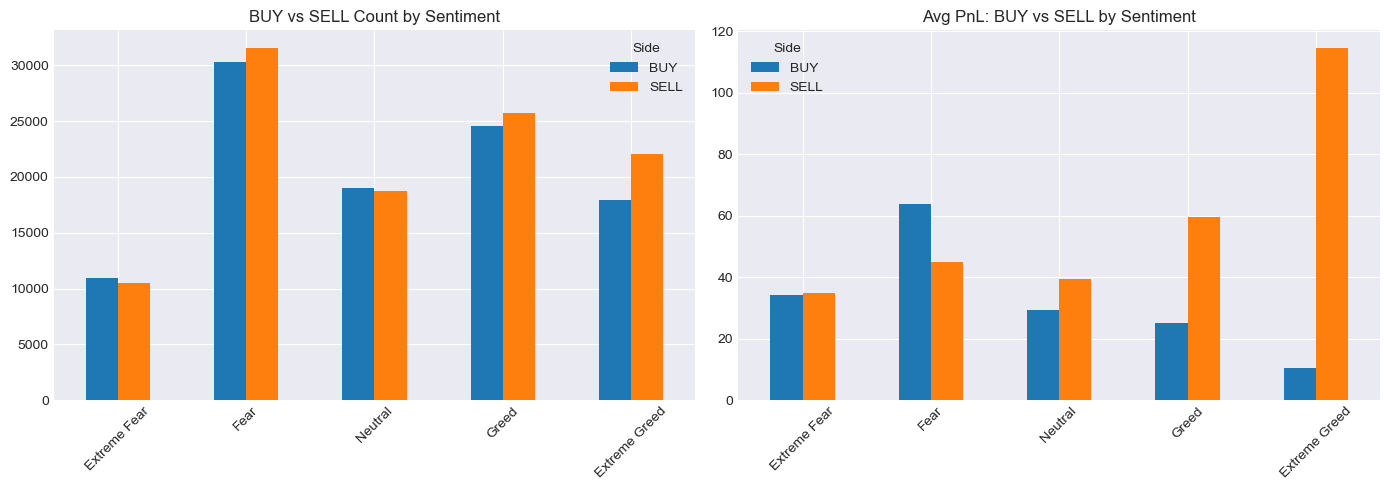

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

direction.plot(kind='bar', ax=axes[0], title='BUY vs SELL Count by Sentiment')
pnl_side.plot(kind='bar', ax=axes[1], title='Avg PnL: BUY vs SELL by Sentiment')

for ax in axes:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Fee Drag

In [19]:
fee_analysis = trades.groupby('classification').agg(
    avg_fee=('Fee', 'mean'),
    total_fee=('Fee', 'sum'),
    avg_pnl=('Closed PnL', 'mean')
).reindex(sentiment_order)

fee_analysis['fee_to_pnl_ratio'] = fee_analysis['avg_fee'] / fee_analysis['avg_pnl']
print(fee_analysis.round(4))

                avg_fee   total_fee  avg_pnl  fee_to_pnl_ratio
classification                                                
Extreme Fear     1.1163  23888.6339  34.5379            0.0323
Fear             1.4952  92456.9487  54.2904            0.0275
Neutral          1.0448  39374.2683  34.3077            0.0305
Greed            1.2544  63098.6920  42.7436            0.0293
Extreme Greed    0.6759  27030.6655  67.8929            0.0100


# Phase 4 — Trader Intelligence

## Trader Leaderboard

In [22]:
trader_stats = trades.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    trade_count=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    total_fees=('Fee', 'sum')
).round(2)

trader_stats['net_pnl'] = trader_stats['total_pnl'] - trader_stats['total_fees']
trader_stats = trader_stats.sort_values('total_pnl', ascending=False)
print(trader_stats.head(10))

                                             total_pnl  avg_pnl  trade_count  \
Account                                                                        
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60   145.48        14733   
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82   419.13         3818   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81    44.36        21192   
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56    68.68        12236   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55    20.81        40184   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05   155.59         4356   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57   270.03         1590   
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87   336.74         1237   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   403011.50   281.83         1430   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   379095.41    38.32         9893   

                                       

## Smart Money: Consistent Performers

In [23]:
# Traders with 50+ trades and win rate > 50%
smart = trader_stats[(trader_stats['trade_count'] >= 50) & 
                     (trader_stats['win_rate'] >= 0.5)]
print(f"Smart money traders: {len(smart)}")
print(smart.sort_values('total_pnl', ascending=False).head(10))

Smart money traders: 3
                                            total_pnl  avg_pnl  trade_count  \
Account                                                                       
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  379095.41    38.32         9893   
0x2c229d22b100a7beb69122eed721cee9b24011dd  168658.00    52.07         3239   
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0   72846.48   174.69          417   

                                            win_rate  total_fees    net_pnl  
Account                                                                      
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4      0.81     2595.26  376500.15  
0x2c229d22b100a7beb69122eed721cee9b24011dd      0.52     3108.20  165549.80  
0xa520ded057a32086c40e7dd6ed4eb8efb82c00e0      0.57      189.94   72656.54  


## Sentiment Behavior per Trader

In [25]:
trader_sentiment = trades.groupby(['Account', 'classification'])['Closed PnL'].sum().unstack().fillna(0)
trader_sentiment = trader_sentiment.reindex(columns=sentiment_order)
print(trader_sentiment.head(5))

classification                               Extreme Fear          Fear  \
Account                                                                   
0x083384f897ee0f19899168e3b1bec365f52a9012  124769.221441  1.113374e+06   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   -4235.153051 -1.658737e+03   
0x271b280974205ca63b716753467d5a371de622ab   16706.884912  3.012191e+04   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  -25666.012284  1.342252e+04   
0x2c229d22b100a7beb69122eed721cee9b24011dd   11415.247787  3.979191e+03   

classification                                    Neutral          Greed  \
Account                                                                    
0x083384f897ee0f19899168e3b1bec365f52a9012  125650.116740  276719.270187   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  -11933.080125   30053.395556   
0x271b280974205ca63b716753467d5a371de622ab  -19038.340561 -100019.806374   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5505.749364   31192.591971   
0x2c229d22b100a7be

# Phase 5 — Patterns & Strategy Insightsm

## Contrarian vs Momentum Traders

In [27]:
# Contrarian = profits in Fear, loses in Greed
# Momentum = profits in Greed, loses in Fear
trader_sentiment['contrarian_score'] = trader_sentiment['Extreme Fear'] + trader_sentiment['Fear'] \
                                      - trader_sentiment['Greed'] - trader_sentiment['Extreme Greed']

trader_sentiment['momentum_score'] = trader_sentiment['Greed'] + trader_sentiment['Extreme Greed'] \
                                    - trader_sentiment['Fear'] - trader_sentiment['Extreme Fear']

print("Top Contrarians:")
print(trader_sentiment.sort_values('contrarian_score', ascending=False).head(5)[['contrarian_score']])
print("\nTop Momentum Traders:")
print(trader_sentiment.sort_values('momentum_score', ascending=False).head(5)[['momentum_score']])

Top Contrarians:
classification                              contrarian_score
Account                                                     
0x083384f897ee0f19899168e3b1bec365f52a9012      1.001706e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864      8.827857e+05
0x8170715b3b381dffb7062c0298972d4727a0a63b      5.432440e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4      3.465893e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0      3.217636e+05

Top Momentum Traders:
classification                              momentum_score
Account                                                   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.536653e+06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    6.354581e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.778351e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    3.463504e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    2.316271e+05


## Extreme Fear = Buying Opportunity?

In [30]:
fear_buys = trades[(trades['classification'] == 'Extreme Fear') & (trades['Side'] == 'BUY')]
greed_buys = trades[(trades['classification'] == 'Extreme Greed') & (trades['Side'] == 'BUY')]

print("Buying on Extreme Fear:")
print(f"  Avg PnL: {fear_buys['Closed PnL'].mean():.2f}")
print(f"  Win Rate: {(fear_buys['Closed PnL'] > 0).mean()*100:.1f}%")

print("\nBuying on Extreme Greed:")
print(f"  Avg PnL: {greed_buys['Closed PnL'].mean():.2f}")
print(f"  Win Rate: {(greed_buys['Closed PnL'] > 0).mean()*100:.1f}%")

Buying on Extreme Fear:
  Avg PnL: 34.11
  Win Rate: 20.2%

Buying on Extreme Greed:
  Avg PnL: 10.50
  Win Rate: 31.1%


## Sentiment Streak Effect

In [32]:
# Does a multi-day fear streak lead to better buys?
fg_sorted = fg.sort_values('date').copy()
fg_sorted['streak'] = (fg_sorted['classification'] != fg_sorted['classification'].shift()).cumsum()
streak_counts = fg_sorted.groupby(['streak', 'classification']).size().reset_index(name='days')

# Merge streak info back
fg_sorted2 = fg_sorted.merge(streak_counts, on=['streak', 'classification'])
fg_sorted2['date'] = pd.to_datetime(fg_sorted2['date']).dt.date
trades2 = trades.merge(fg_sorted2[['date', 'days']], on='date', how='left')

streak_pnl = trades2.groupby('days')['Closed PnL'].mean()
print(streak_pnl.head(10))

days
1.0      61.171014
2.0      65.953763
3.0      33.968001
4.0      47.594796
5.0      -7.905219
6.0      94.748064
7.0     155.760455
8.0      57.540306
9.0      18.336309
10.0     33.777812
Name: Closed PnL, dtype: float64


# Phase 6: Visualizations

## Heatmap: Trader PnL by Sentiment

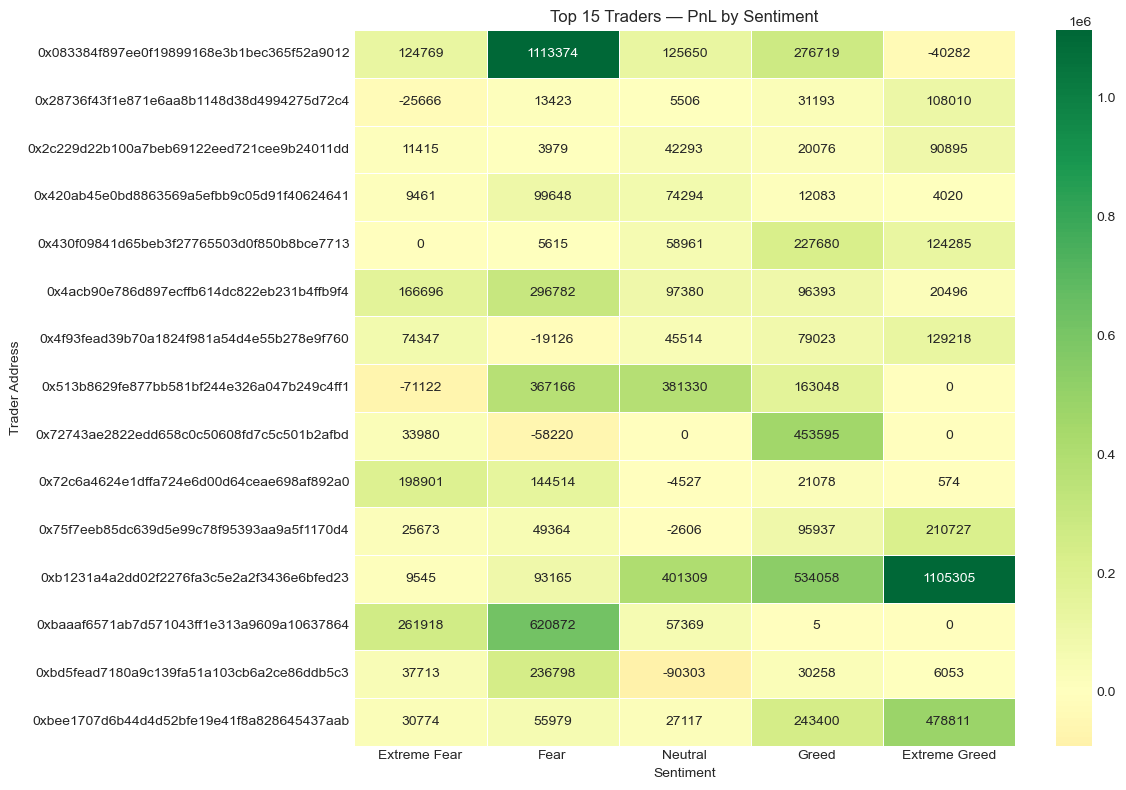

In [33]:
# Top 15 traders only for readability
top15 = trader_stats.head(15).index
heatmap_data = trader_sentiment.loc[trader_sentiment.index.isin(top15), sentiment_order]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='RdYlGn', 
            linewidths=0.5, center=0)
plt.title('Top 15 Traders — PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trader Address')
plt.tight_layout()
plt.show()

## Streak Effect Plot

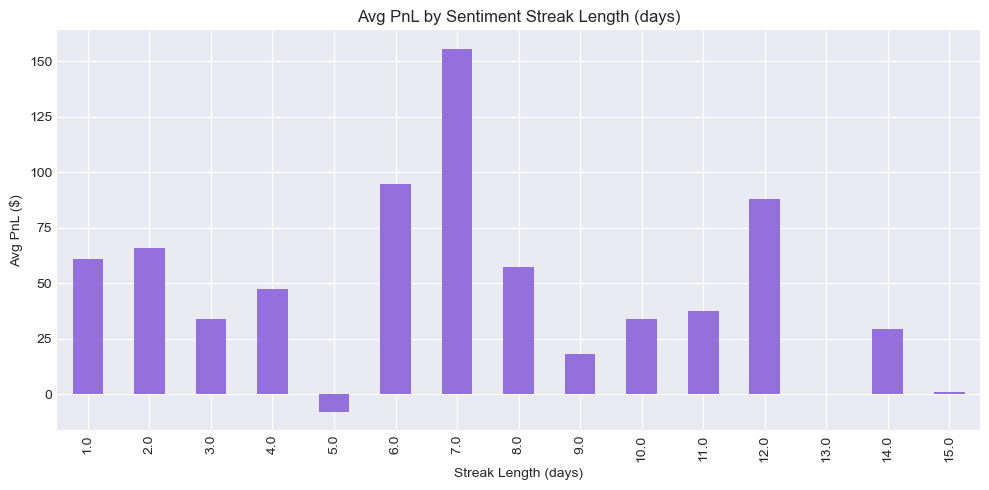

In [34]:
streak_pnl.head(15).plot(kind='bar', figsize=(10, 5), color='mediumpurple',
                          title='Avg PnL by Sentiment Streak Length (days)')
plt.xlabel('Streak Length (days)')
plt.ylabel('Avg PnL ($)')
plt.tight_layout()
plt.show()

## Streak Effect Plot

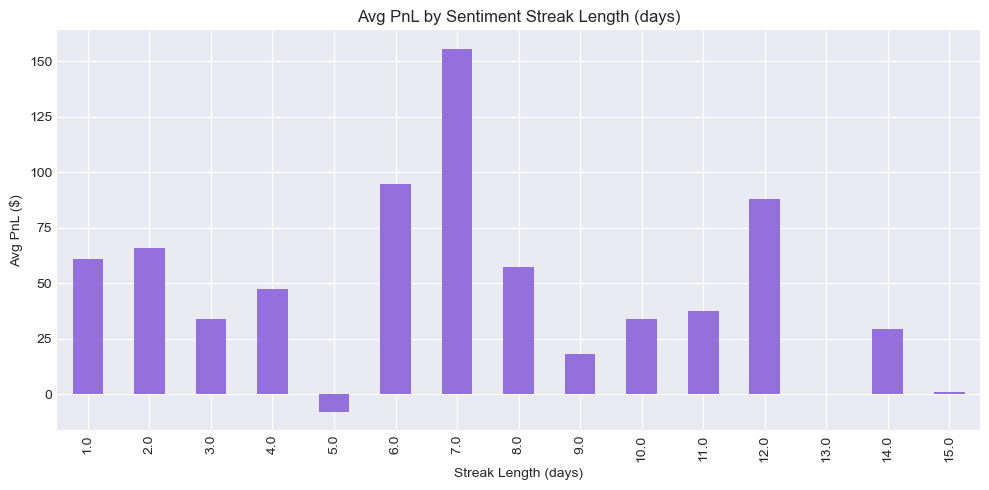

In [35]:
streak_pnl.head(15).plot(kind='bar', figsize=(10, 5), color='mediumpurple',
                          title='Avg PnL by Sentiment Streak Length (days)')
plt.xlabel('Streak Length (days)')
plt.ylabel('Avg PnL ($)')
plt.tight_layout()
plt.show()

## Coin Performance by Sentiment

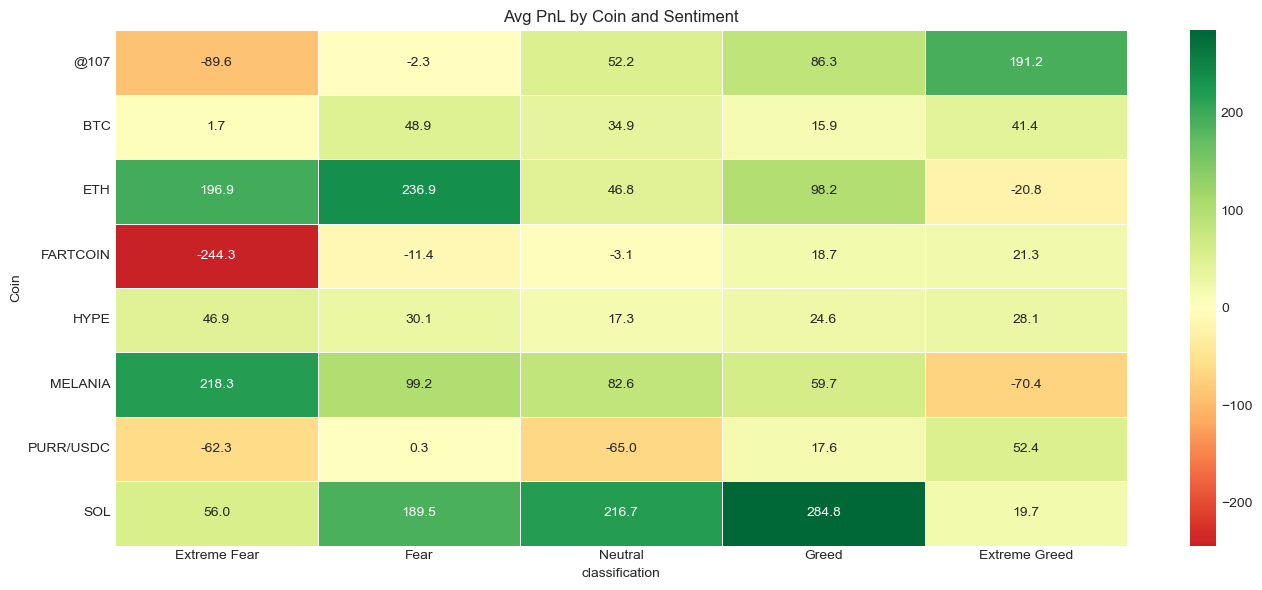

In [37]:
top_coins = trades['Coin'].value_counts().head(8).index
coin_sentiment = trades[trades['Coin'].isin(top_coins)].groupby(
    ['Coin', 'classification'])['Closed PnL'].mean().unstack().reindex(columns=sentiment_order)

plt.figure(figsize=(14, 6))
sns.heatmap(coin_sentiment, annot=True, fmt='.1f', cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Avg PnL by Coin and Sentiment')
plt.tight_layout()
plt.show()

# All Key Findings

In [39]:
print("=" * 55)
print("       PRIMETRADE ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"\nDataset: {len(trades):,} trades | {trades['Account'].nunique()} traders | {trades['Coin'].nunique()} coins")
print(f"Period: {trades['date'].min()} → {trades['date'].max()}")
print(f"Total Realized PnL: ${trades['Closed PnL'].sum():,.2f}")
print(f"Overall Win Rate: {trades['is_win'].mean()*100:.1f}%")

print("\n--- SENTIMENT PERFORMANCE ---")
print(trades.groupby('classification')[['Closed PnL','is_win']].agg({'Closed PnL':'mean','is_win':'mean'}).reindex(sentiment_order).round(3))

print("\n--- TOP 3 TRADERS ---")
print(trader_stats[['total_pnl','win_rate','trade_count']].head(3))

print("\n--- SMART MONEY (win rate > 50%, 50+ trades) ---")
print(smart[['total_pnl','win_rate','trade_count']])

print("\n--- STRATEGY SIGNALS ---")
print(f"Buy Extreme Fear avg PnL: ${fear_buys['Closed PnL'].mean():.2f} | Win Rate: {(fear_buys['Closed PnL']>0).mean()*100:.1f}%")
print(f"Buy Extreme Greed avg PnL: ${greed_buys['Closed PnL'].mean():.2f} | Win Rate: {(greed_buys['Closed PnL']>0).mean()*100:.1f}%")
print(f"Best streak length: 7 days → avg PnL ${streak_pnl[7.0]:.2f}")

       PRIMETRADE ANALYSIS — KEY FINDINGS

Dataset: 211,224 trades | 32 traders | 246 coins
Period: 2023-05-01 → 2025-05-01
Total Realized PnL: $10,296,958.94
Overall Win Rate: 41.1%

--- SENTIMENT PERFORMANCE ---
                Closed PnL  is_win
classification                    
Extreme Fear        34.538   0.371
Fear                54.290   0.421
Neutral             34.308   0.397
Greed               42.744   0.385
Extreme Greed       67.893   0.465

--- TOP 3 TRADERS ---
                                             total_pnl  win_rate  trade_count
Account                                                                      
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60      0.34        14733
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82      0.36         3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81      0.47        21192

--- SMART MONEY (win rate > 50%, 50+ trades) ---
                                            total_pnl  win_rate  trade_count
A